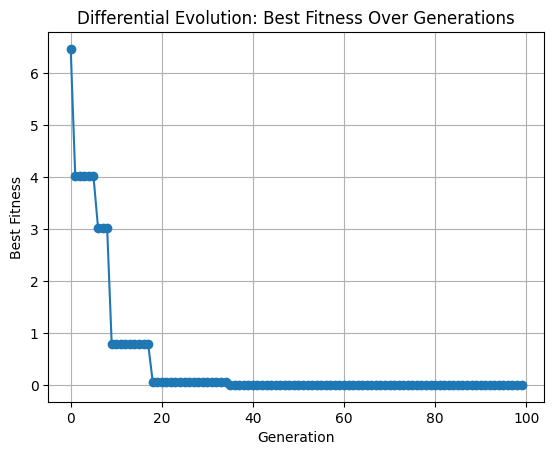

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

def rosenbrock(x):
    a = 1
    b = 100
    return (a - x[0])**2 + b * (x[1] - x[0]**2)**2

def initialize_population(pop_size, dim, bounds):
    population = np.random.rand(pop_size, dim)
    min_b, max_b = np.asarray(bounds).T
    diff = np.fabs(min_b - max_b)
    population = min_b + population * diff
    return population

def mutation(population, F):
    pop_size = len(population)
    mutated_pop = np.zeros_like(population)

    for i in range(pop_size):
        indices = np.random.choice(np.delete(np.arange(pop_size), i), 3, replace=False)
        x1, x2, x3 = population[indices]
        mutated_pop[i] = x1 + F * (x2 - x3)

    return mutated_pop

def crossover(population, mutated_pop, Cr):
    pop_size, dim = population.shape
    trial_pop = np.zeros_like(population)

    for i in range(pop_size):
        crossover_points = np.random.rand(dim) < Cr
        j_rand = np.random.randint(dim)
        crossover_points[j_rand] = True
        trial_pop[i] = np.where(crossover_points, mutated_pop[i], population[i])

    return trial_pop

def selection(population, trial_pop, fitness_fn):
    pop_size = len(population)
    new_population = np.zeros_like(population)

    for i in range(pop_size):
        if fitness_fn(trial_pop[i]) < fitness_fn(population[i]):
            new_population[i] = trial_pop[i]
        else:
            new_population[i] = population[i]

    return new_population

def differential_evolution(fitness_fn, bounds, pop_size=20, F=0.5, Cr=0.7, max_generations=100):
    dim = len(bounds)
    population = initialize_population(pop_size, dim, bounds)

    best_fitness_over_time = []

    for generation in range(max_generations):
        mutated_pop = mutation(population, F)
        trial_pop = crossover(population, mutated_pop, Cr)
        population = selection(population, trial_pop, fitness_fn)

        best_idx = np.argmin([fitness_fn(ind) for ind in population])
        best_individual = population[best_idx]
        best_fitness = fitness_fn(best_individual)

        best_fitness_over_time.append(best_fitness)

    best_idx = np.argmin([fitness_fn(ind) for ind in population])
    return population[best_idx], fitness_fn(population[best_idx]), best_fitness_over_time

bounds = [(-5, 5), (-5, 5)]

best_solution, best_fitness, best_fitness_over_time = differential_evolution(rosenbrock, bounds, pop_size=30, F=0.8, Cr=0.9, max_generations=100)

plt.plot(best_fitness_over_time, marker='o')
plt.title('Differential Evolution: Best Fitness Over Generations')
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.grid(True)
plt.show()